# Grasp adaptation — compliance sensing + gradient-descent force control

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../'))
from hand_config import (K_TIP_GENTLE, K_TIP_PROBE, K_TIP_HOLD,
                         F_GAIN, GD_LR, F_CONVERGE_THR)

OUTPUT_DIR  = os.path.join('outputs', 'grasp_adaptation')
OBJECTS     = ['hard_obj', 'soft_obj']
MODES       = ['stiffness', 'ref']
OBJ_LABELS  = {'hard_obj': 'Hard', 'soft_obj': 'Soft'}
MODE_LABELS = {'stiffness': 'Stiffness descent', 'ref': 'Ref descent'}
OBJ_COLOR   = {'hard_obj': '#0072B2', 'soft_obj': '#D55E00'}
MODE_LS     = {'stiffness': '-', 'ref': '--'}

def load(obj, mode):
    folder = Path(OUTPUT_DIR)
    if not folder.exists():
        return None
    files = sorted(folder.glob(f'grasp_{obj}_{mode}.csv'))
    return pd.read_csv(files[-1]) if files else None

data = {obj: {mode: load(obj, mode) for mode in MODES} for obj in OBJECTS}
print('Loaded:')
for obj in OBJECTS:
    for mode in MODES:
        df = data[obj][mode]
        print(f'  {obj}/{mode}: {len(df)} rows' if df is not None else f'  {obj}/{mode}: no data')

Loaded:
  hard_obj/stiffness: 680 rows
  hard_obj/ref: no data
  soft_obj/stiffness: no data
  soft_obj/ref: no data


## Compliance estimate $C_O^{\rm thumb}$

$C_O = \|\Delta x_{\rm thumb}\| / \|\Delta F_{\rm thumb}\|$ from the sense → probe finite difference.
Lower = stiffer object. Both modes run the same sensing protocol so $C_O$ should match.

/tmp/ipykernel_18972/1950808125.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


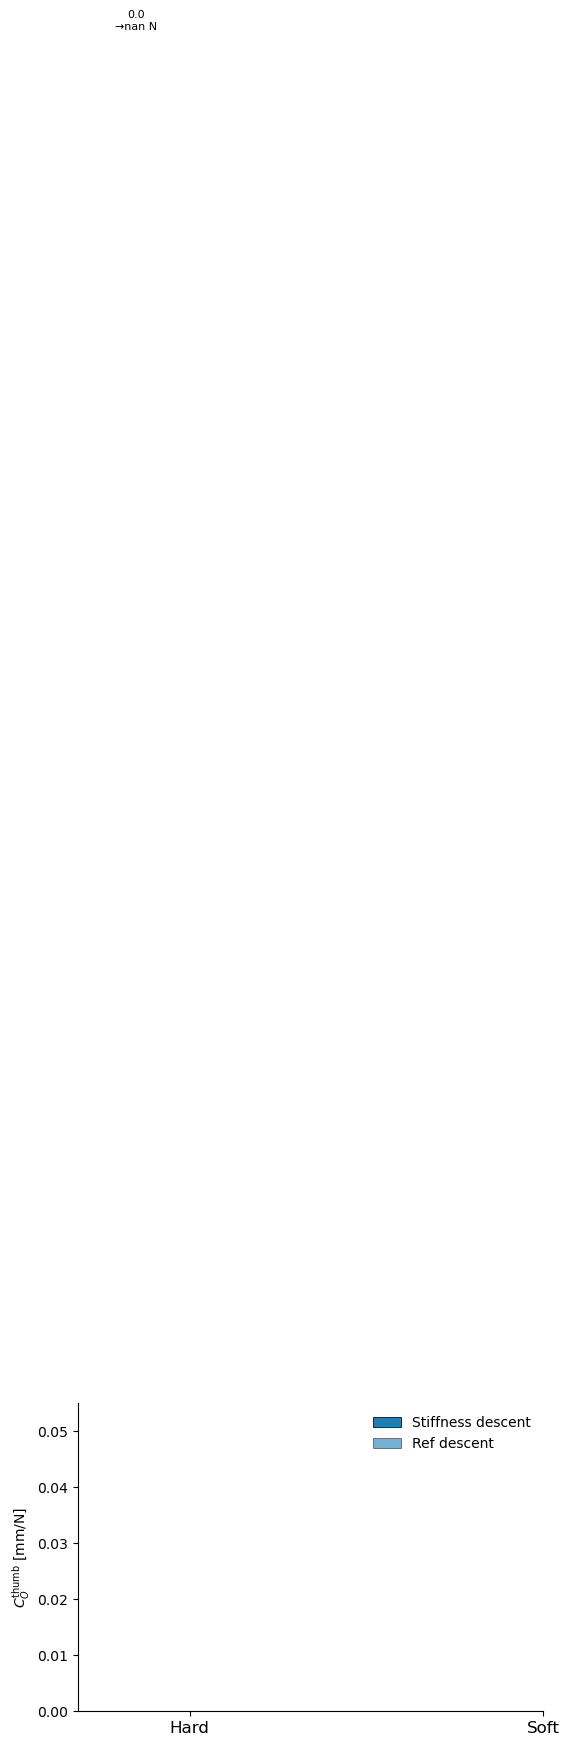

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))

x     = np.arange(len(OBJECTS))
width = 0.3
os.makedirs(OUTPUT_DIR, exist_ok=True)

for mi, mode in enumerate(MODES):
    C_Os = []
    f_des_vals = []
    for obj in OBJECTS:
        df = data[obj][mode]
        if df is None:
            C_Os.append(np.nan); f_des_vals.append(np.nan); continue
        # C_O is stored directly in the CSV; take median over probe phase
        probe = df[df['phase'] == 'probe']
        C_O   = float(probe['C_O_m_per_N'].median()) if not probe.empty else np.nan
        f_des = F_GAIN / C_O if C_O > 1e-12 else np.nan
        C_Os.append(C_O * 1e3)
        f_des_vals.append(f_des)

    bars = ax.bar(x + (mi - 0.5) * width, C_Os, width,
                  color=[OBJ_COLOR[o] for o in OBJECTS],
                  alpha=(0.9 if mode == 'stiffness' else 0.55),
                  edgecolor='k', linewidth=0.6,
                  label=MODE_LABELS[mode])
    for bar, C_O_val, f_des_val in zip(bars, C_Os, f_des_vals):
        if not np.isnan(C_O_val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f'{C_O_val:.1f}\n→{f_des_val:.2f} N',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([OBJ_LABELS[o] for o in OBJECTS], fontsize=12)
ax.set_ylabel(r'$C_O^{\mathrm{thumb}}$ [mm/N]')
ax.set_ylim(0, None)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_compliance.pdf'), bbox_inches='tight')
plt.show()

## GD convergence: $\|f_{\rm meas} - f_{\rm des}\|$ over time

One panel per object. Both modes overlaid. Dashed horizontal line = `F_CONVERGE_THR`.

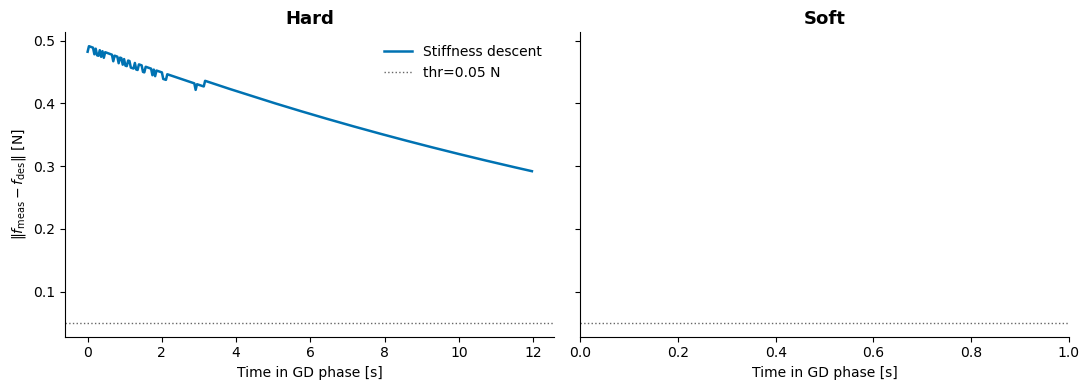

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, obj in zip(axes, OBJECTS):
    for mode in MODES:
        df = data[obj][mode]
        if df is None:
            continue
        gd = df[df['phase'] == 'adapt_gd']
        if gd.empty:
            continue
        t0    = gd['time_s'].iloc[0]
        f_err = np.linalg.norm(
            gd[['f_meas_gd_x_N','f_meas_gd_y_N','f_meas_gd_z_N']].to_numpy() -
            gd[['f_des_x_N','f_des_y_N','f_des_z_N']].to_numpy(),
            axis=1)
        ax.plot(gd['time_s'] - t0, f_err,
                color=OBJ_COLOR[obj], ls=MODE_LS[mode], lw=1.8,
                label=MODE_LABELS[mode])
    ax.axhline(F_CONVERGE_THR, color='0.4', lw=1, ls=':', label=f'thr={F_CONVERGE_THR} N')
    ax.set_title(OBJ_LABELS[obj], fontsize=13, fontweight='bold')
    ax.set_xlabel('Time in GD phase [s]')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel(r'$\|f_{\rm meas} - f_{\rm des}\|$ [N]')
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gd_convergence.pdf'), bbox_inches='tight')
plt.show()

## Adapted parameter evolution during GD

**Stiffness mode**: mean diagonal of thumb task K [N/m].  
**Ref mode**: displacement of thumb virtual equilibrium from its initial position [mm].

/tmp/ipykernel_18972/3370343955.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ref.legend(frameon=False)


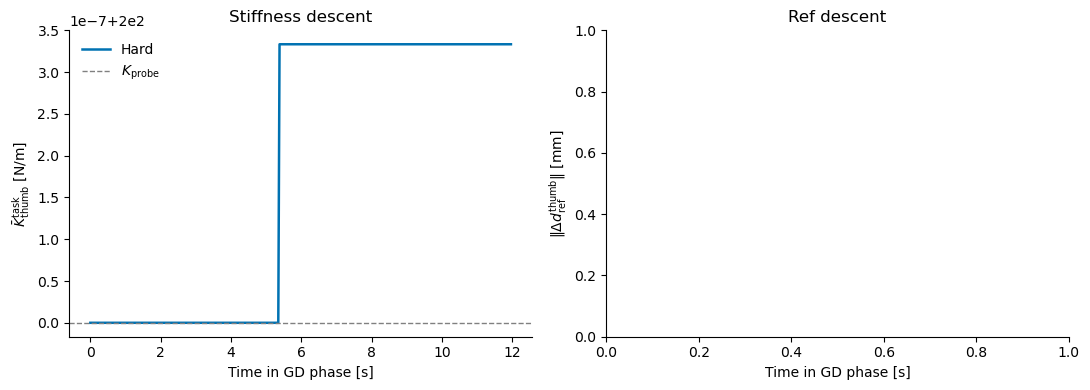

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax_stiff, ax_ref = axes

for obj in OBJECTS:
    for mode in MODES:
        df = data[obj][mode]
        if df is None:
            continue
        gd = df[df['phase'] == 'adapt_gd']
        if gd.empty:
            continue
        t0    = gd['time_s'].iloc[0]
        label = f'{OBJ_LABELS[obj]}'

        if mode == 'stiffness':
            K_mean = gd[['K_thumb_task_00_Npm',
                          'K_thumb_task_11_Npm',
                          'K_thumb_task_22_Npm']].mean(axis=1)
            ax_stiff.plot(gd['time_s'] - t0, K_mean,
                          color=OBJ_COLOR[obj], lw=1.8, label=label)
        else:
            d_ref0 = gd[['d_ref_thumb_x_m','d_ref_thumb_y_m','d_ref_thumb_z_m']].iloc[0].to_numpy()
            disp   = np.linalg.norm(
                gd[['d_ref_thumb_x_m','d_ref_thumb_y_m','d_ref_thumb_z_m']].to_numpy() - d_ref0,
                axis=1) * 1e3
            ax_ref.plot(gd['time_s'] - t0, disp,
                        color=OBJ_COLOR[obj], lw=1.8, label=label)

ax_stiff.axhline(K_TIP_PROBE, color='0.5', lw=1, ls='--', label=r'$K_{\rm probe}$')
ax_stiff.set_ylabel(r'$\bar{K}_{\rm thumb}^{\rm task}$ [N/m]')
ax_stiff.set_xlabel('Time in GD phase [s]')
ax_stiff.set_title('Stiffness descent', fontsize=12)
ax_stiff.legend(frameon=False)
ax_stiff.spines[['top', 'right']].set_visible(False)

ax_ref.set_ylabel(r'$\|\Delta d_{\rm ref}^{\rm thumb}\|$ [mm]')
ax_ref.set_xlabel('Time in GD phase [s]')
ax_ref.set_title('Ref descent', fontsize=12)
ax_ref.legend(frameon=False)
ax_ref.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gd_param_evolution.pdf'), bbox_inches='tight')
plt.show()

## Thumb force during lift

$\|F_{\rm thumb}\|$ during the `lift` phase. Each object × mode combination shown.
This is the key outcome: does the adapted controller produce the right force when the object leaves the surface?

/tmp/ipykernel_18972/846788406.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


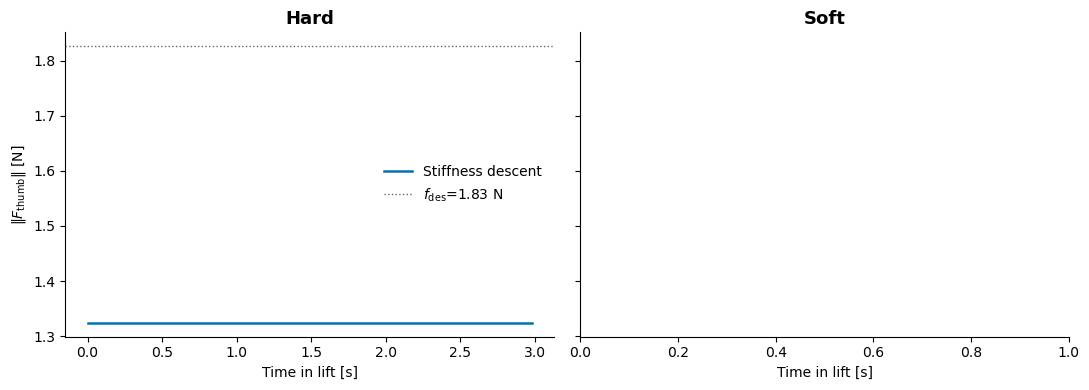

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, obj in zip(axes, OBJECTS):
    for mode in MODES:
        df = data[obj][mode]
        if df is None:
            continue
        lift = df[df['phase'] == 'lift']
        if lift.empty:
            continue
        t0   = lift['time_s'].iloc[0]
        Fmag = np.linalg.norm(
            lift[['force_1st_thumb_x_N','force_1st_thumb_y_N','force_1st_thumb_z_N']].to_numpy(),
            axis=1)
        f_des_mag = float(lift['f_des_mag_N'].iloc[0])
        ax.plot(lift['time_s'] - t0, Fmag,
                color=OBJ_COLOR[obj], ls=MODE_LS[mode], lw=1.8,
                label=f'{MODE_LABELS[mode]}')
    # target force (same for both modes since C_O is the same)
    df0 = data[obj][MODES[0]]
    if df0 is not None:
        lift0 = df0[df0['phase'] == 'lift']
        if not lift0.empty:
            f_des_mag = float(lift0['f_des_mag_N'].iloc[0])
            ax.axhline(f_des_mag, color='0.4', lw=1, ls=':',
                       label=f'$f_{{\\rm des}}$={f_des_mag:.2f} N')
    ax.set_title(OBJ_LABELS[obj], fontsize=13, fontweight='bold')
    ax.set_xlabel('Time in lift [s]')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False)

axes[0].set_ylabel(r'$\|F_{\rm thumb}\|$ [N]')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_force_lift.pdf'), bbox_inches='tight')
plt.show()

## Hand pose during lift

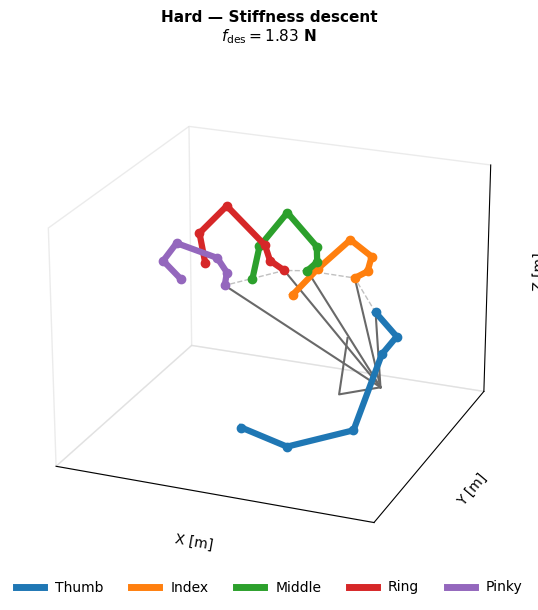

In [6]:
from ModelIDHand.hand_viz import plot_hand, _COL

_Q_COLS        = [f'q_motor_{i}_rad' for i in range(13)]
FINGERTIPS_VIZ = ['thumb', 'index', 'middle', 'ring', 'pinky']
_STYLE         = dict(linestyle='-', linewidth=4.5, marker='o', markersize=6.0)
_ELEV, _AZIM   = 22, 112

# One panel per object × mode combination that has lift data
panels = [(obj, mode)
          for obj in OBJECTS for mode in MODES
          if data[obj][mode] is not None and not data[obj][mode][data[obj][mode]['phase']=='lift'].empty]

fig = plt.figure(figsize=(6 * len(panels), 6))
fig.patch.set_facecolor('white')
axes3d = []

for i, (obj, mode) in enumerate(panels):
    df   = data[obj][mode]
    lift = df[df['phase'] == 'lift']
    q    = lift[_Q_COLS].iloc[len(lift) // 2].to_numpy(dtype=np.float64)
    ax3d = fig.add_subplot(1, len(panels), i + 1, projection='3d')
    plot_hand(q, ax=ax3d, style=_STYLE)
    leg = ax3d.get_legend()
    if leg: leg.remove()
    ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
    for pane in (ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane):
        pane.fill = False; pane.set_edgecolor('#d8d8d8')
    ax3d.view_init(elev=_ELEV, azim=_AZIM)
    f_des_mag = float(lift['f_des_mag_N'].iloc[0])
    ax3d.set_title(f"{OBJ_LABELS[obj]} — {MODE_LABELS[mode]}\n$f_{{\\rm des}}={f_des_mag:.2f}$ N",
                   fontsize=11, fontweight='semibold', pad=14)
    axes3d.append(ax3d)

# sync axis limits
if axes3d:
    lims = np.array([[a.get_xlim3d(), a.get_ylim3d(), a.get_zlim3d()] for a in axes3d])
    xl = [lims[:,0,0].min(), lims[:,0,1].max()]
    yl = [lims[:,1,0].min(), lims[:,1,1].max()]
    zl = [lims[:,2,0].min(), lims[:,2,1].max()]
    span = max(xl[1]-xl[0], yl[1]-yl[0], zl[1]-zl[0])
    cx, cy, cz = sum(xl)/2, sum(yl)/2, sum(zl)/2
    for a in axes3d:
        a.set_xlim3d(cx-span/2, cx+span/2)
        a.set_ylim3d(cy-span/2, cy+span/2)
        a.set_zlim3d(cz-span/2, cz+span/2)

_LEG = [plt.Line2D([0],[0], color=_COL[n], lw=5, label=n.capitalize())
        for n in FINGERTIPS_VIZ]
fig.legend(handles=_LEG, loc='lower center', ncol=5, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'lift_hand_pose.pdf'), bbox_inches='tight', dpi=300)
plt.show()